# Pipeline AR

**Fluxo:**
1. Carrega série e plota
2. Calcula autocovariância / autocorrelação (manual + ACF/PACF do statsmodels)
3. Testes de estacionariedade: **ADF** e **KPSS**
4. **Gate:** se não estacionária → para aqui
5. Se estacionária → treino/teste, busca melhor `p` via BIC, ajusta AR(p), prevê, MAE/MAPE, plota, diagnóstico Ljung-Box

**Datasets (Kaggle):**
| Dataset | Esperado | Fonte |
|---|---|---|
| Air Passengers | Não estacionária | `rakannimer/air-passengers` |
| Daily Min Temperatures (Melbourne) | Estacionária | `shenba/time-series-datasets` |
| Monthly Sunspots | Estacionária | `robervalt/sunspots` |
| Gold Prices | Não estacionária | `altruistdelhite04/gold-price-data` |

## 1. Imports

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error

## 2. Funções

In [10]:
def autocovariance(series, lag):
    series = np.asarray(series)
    n = len(series)
    mean = np.mean(series)
    return np.sum((series[lag:] - mean) * (series[:n - lag] - mean)) / n

def autocorrelation(series, lag):
    return autocovariance(series, lag) / autocovariance(series, 0)

def kpss_test(series):
    resultado = kpss(series, regression='c')
    print('KPSS Statistic: %f' % resultado[0])
    print('p-value: %f' % resultado[1])
    print('Critical Values:')
    for key, value in resultado[3].items():
        print('\t%s: %.3f' % (key, value))
    return resultado[1]

def adf_test(series):
    resultado = adfuller(series)
    print('ADF Statistic: %f' % resultado[0])
    print('p-value: %f' % resultado[1])
    print('Critical Values:')
    for key, value in resultado[4].items():
        print('\t%s: %.3f' % (key, value))
    return resultado[1]

## 3. Pipeline


A função abaixo executa as duas etapas dos notebooks:
- **Etapa 1** — Análise de autocorrelação + testes ADF/KPSS
- **Etapa 2** — (só se estacionária) Modelagem AR(p), previsão e diagnóstico de resíduos

In [ ]:
def pipeline_ar(serie_original, nome_dataset, max_lag=20, p_max=20, alpha=0.05):
    print(f"DATASET: {nome_dataset}")

    if isinstance(serie_original, pd.DataFrame):
        serie_original = serie_original.iloc[:, 0]
    serie_original = serie_original.reset_index(drop=True)

    plt.figure(figsize=(10, 4))
    plt.plot(serie_original)
    plt.title(f'Série Original - {nome_dataset}')
    plt.xlabel('Tempo'); plt.ylabel('Valor')
    plt.tight_layout(); plt.show()

    serie = serie_original[:-1]
    teste = serie_original[-1:]

    plt.figure(figsize=(10, 4))
    plt.plot(serie_original, label='série')
    plt.axvline(x=len(serie) - 1, color='red', linestyle='--', label='treino-teste')
    plt.title(f'Split Treino/Teste - {nome_dataset}')
    plt.legend(); plt.tight_layout(); plt.show()

    lags = range(0, max_lag + 1)
    auto_cov = [autocovariance(serie, lag) for lag in lags]
    auto_corr = [autocorrelation(serie, lag) for lag in lags]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(lags, auto_cov, marker='o')
    axes[0].set_title(f'Autocovariância - {nome_dataset}')
    axes[0].set_xlabel('Lag'); axes[0].grid()
    axes[1].plot(lags, auto_corr, marker='o', color='orange')
    axes[1].set_title(f'Autocorrelação (manual) - {nome_dataset}')
    axes[1].set_xlabel('Lag'); axes[1].grid()
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(8, 4))
    plot_acf(serie, lags=max_lag, ax=plt.gca(),
             title=f'ACF - {nome_dataset}')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(8, 4))
    plot_pacf(serie, lags=max_lag, ax=plt.gca(),
              title=f'PACF - {nome_dataset}')
    plt.tight_layout(); plt.show()

    print('\nTeste KPSS')
    p_kpss = kpss_test(serie)

    print('\nTeste ADF')
    p_adf = adf_test(serie)

    adf_estac = p_adf < alpha
    kpss_estac = p_kpss > alpha
    estacionaria = adf_estac and kpss_estac

    print('\nDecisão')
    print(f'ADF -> {"estacionária" if adf_estac else "NÃO estacionária"}')
    print(f'KPSS -> {"estacionária" if kpss_estac else "NÃO estacionária"}')
    print(f'Veredito: {"ESTACIONÁRIA" if estacionaria else "NÃO ESTACIONÁRIA"}')

    if not estacionaria:
        print('\n> Série não estacionária')
        return {
            'dataset': nome_dataset,
            'estacionaria': False,
            'p_adf': p_adf,
            'p_kpss': p_kpss,
        }

    print('\nBusca do melhor p (critério BIC)')
    melhor_p = None
    melhor_modelo = None
    menor_bic = np.inf

    for p in range(1, p_max + 1):
        m = AutoReg(serie, lags=p, old_names=False).fit()
        if m.bic < menor_bic:
            melhor_p = p
            melhor_modelo = m
            menor_bic = m.bic

    print(f'Melhor p: {melhor_p}')
    print(f'Menor BIC: {menor_bic:.4f}')

    modelo_final = AutoReg(serie, lags=melhor_p, old_names=False).fit()
    previsao = modelo_final.predict(start=len(serie), end=len(serie)).iloc[0]
    valor_real = float(teste.values[0])

    mae_teste = mean_absolute_error([valor_real], [previsao])
    mape_teste = abs(mae_teste / valor_real) * 100 if valor_real != 0 else float('nan')

    print('\nPrevisão 1-step')
    print(f'Previsão : {previsao:.4f}')
    print(f'Real     : {valor_real:.4f}')
    print(f'MAE      : {mae_teste:.4f}')
    print(f'MAPE     : {mape_teste:.4f}%')

    serie_ajustada = modelo_final.predict(start=melhor_p, end=len(serie) - 1)
    x_fit = np.arange(melhor_p, len(serie))

    plt.figure(figsize=(10, 5))
    line_orig, = plt.plot(serie_original.values, label='Série original')
    line_fit, = plt.plot(x_fit, serie_ajustada, label=f'Ajuste AR({melhor_p})')
    plt.scatter([len(serie)], [valor_real], s=90, marker='x',
                color=line_orig.get_color(), label='Valor real (teste)')
    plt.scatter([len(serie)], [previsao], s=90, marker='o',
                color=line_fit.get_color(), label='Previsão')
    plt.title(f'Ajuste + Previsão - {nome_dataset}')
    plt.legend(); plt.tight_layout(); plt.show()

    print('\nDiagnóstico dos resíduos')
    res = modelo_final.resid
    lb = acorr_ljungbox(res, lags=[20])
    print('Ljung-Box (lag=20):')
    print(lb)
    if lb['lb_pvalue'].values[0] > alpha:
        print('p > 0.05: resíduos parecem ruído branco')
    else:
        print('p < 0.05: ainda há autocorrelação nos resíduos')

    plt.figure(figsize=(8, 4))
    plot_acf(res, lags=20, ax=plt.gca(),
             title=f'ACF dos resíduos - {nome_dataset}')
    plt.tight_layout(); plt.show()

    return {
        'dataset': nome_dataset,
        'estacionaria': True,
        'p_adf': p_adf,
        'p_kpss': p_kpss,
        'melhor_p': melhor_p,
        'bic': menor_bic,
        'previsao': previsao,
        'real': valor_real,
        'mae': mae_teste,
        'mape': mape_teste,
        'ljung_box_p': lb['lb_pvalue'].values[0],
    }

## 4. Execução nos 4 datasets

### 4.1 Air Passengers (esperado: **não estacionária**)

DATASET: Air Passengers


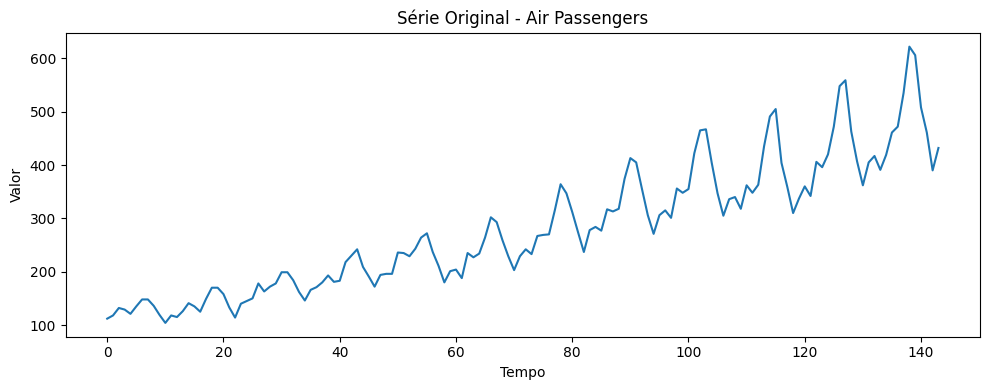

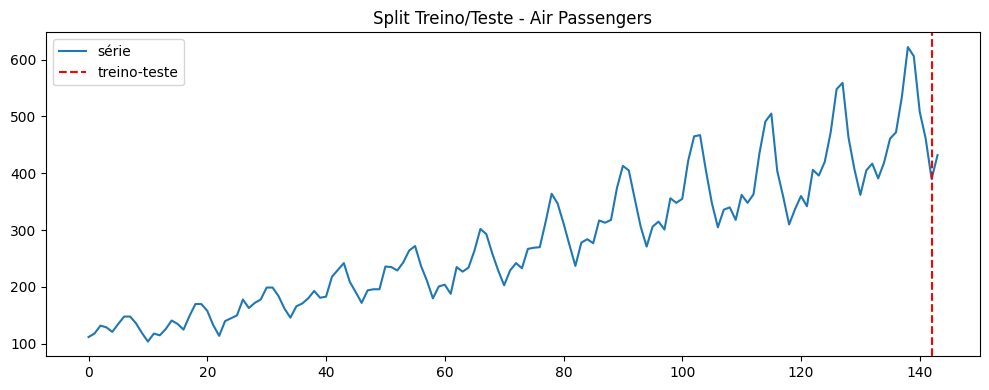

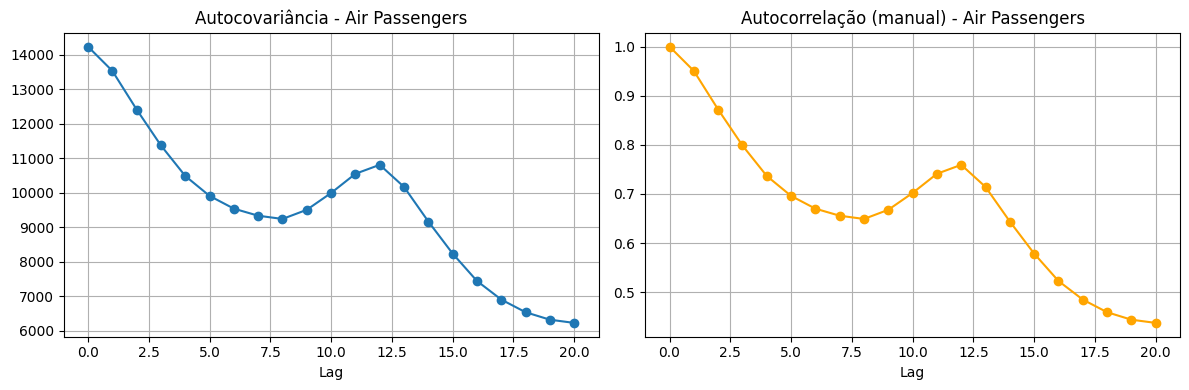

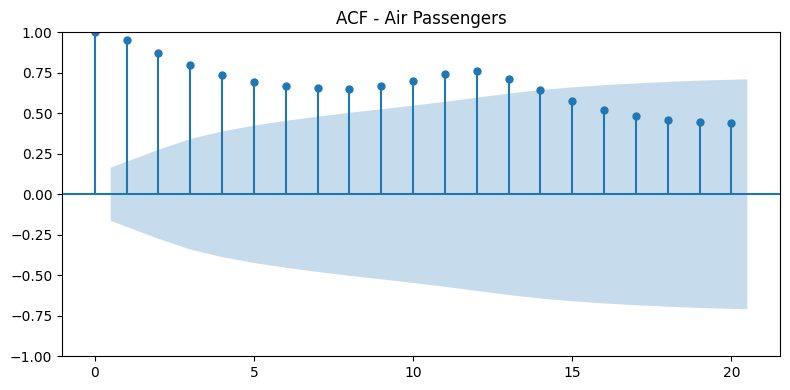

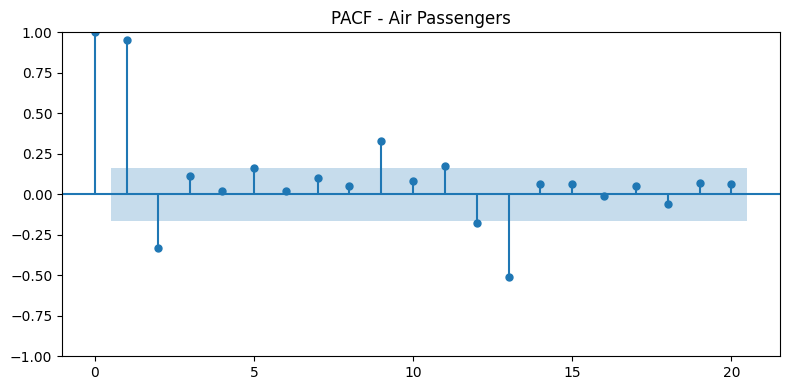


Teste KPSS
KPSS Statistic: 1.647351
p-value: 0.010000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739

Teste ADF
ADF Statistic: 0.858591
p-value: 0.992525
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579

Decisão
ADF -> NÃO estacionária
KPSS -> NÃO estacionária
Veredito: NÃO ESTACIONÁRIA

> Série não estacionária


In [12]:
df_air = pd.read_csv('data/air_passengers.csv')
serie_air = df_air['Passengers']
r1 = pipeline_ar(serie_air, 'Air Passengers')

### 4.2 Daily Min Temperatures Melbourne (esperado: **estacionária**)

DATASET: Melbourne Daily Min Temperatures


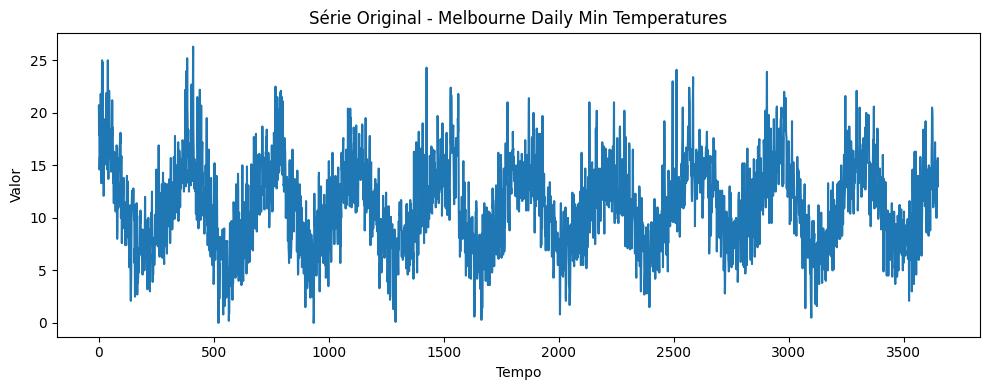

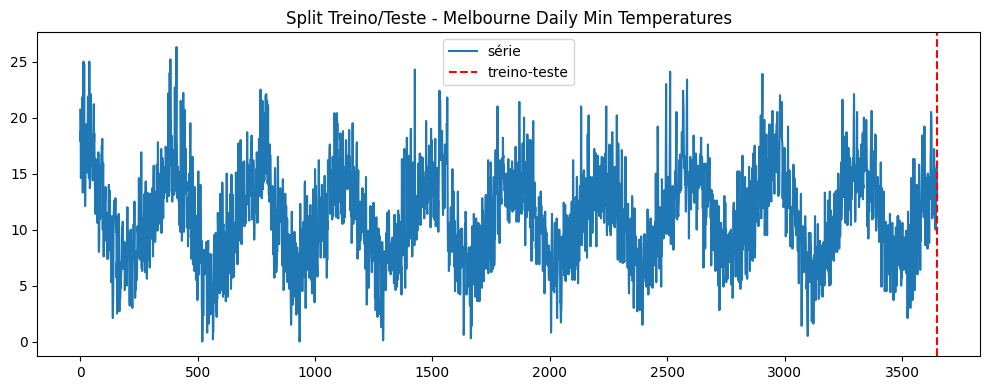

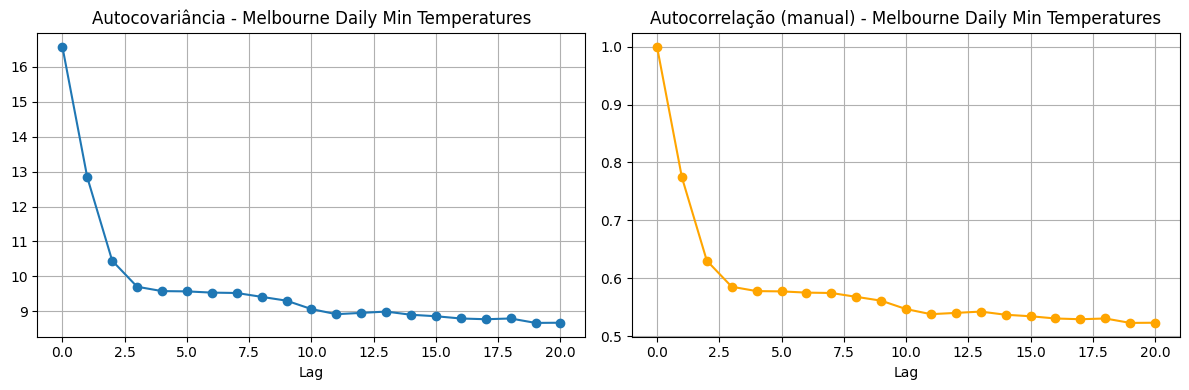

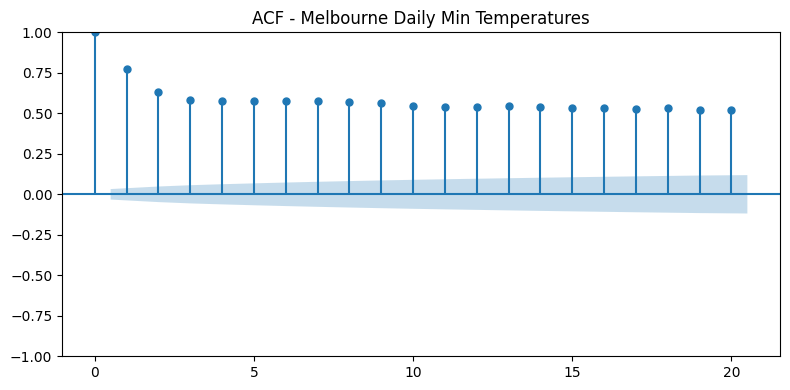

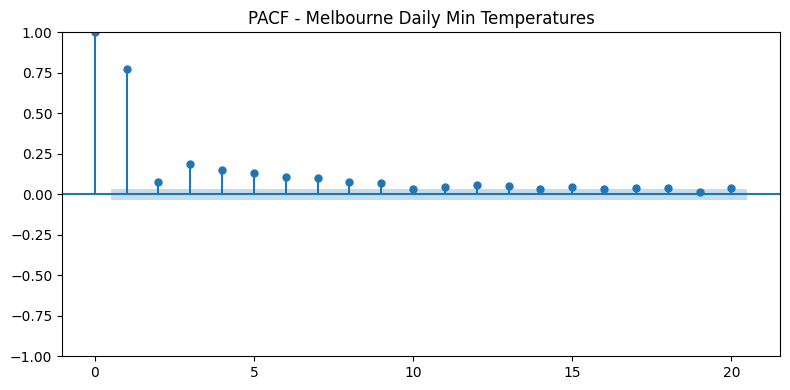


Teste KPSS
KPSS Statistic: 0.055554
p-value: 0.100000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739

Teste ADF
ADF Statistic: -4.436758
p-value: 0.000255
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567

Decisão
ADF -> estacionária
KPSS -> estacionária
Veredito: ESTACIONÁRIA

Busca do melhor p (critério BIC)
Melhor p: 20
Menor BIC: 16827.0346

Previsão 1-step
Previsão : 14.4842
Real     : 13.0000
MAE      : 1.4842
MAPE     : 11.4166%


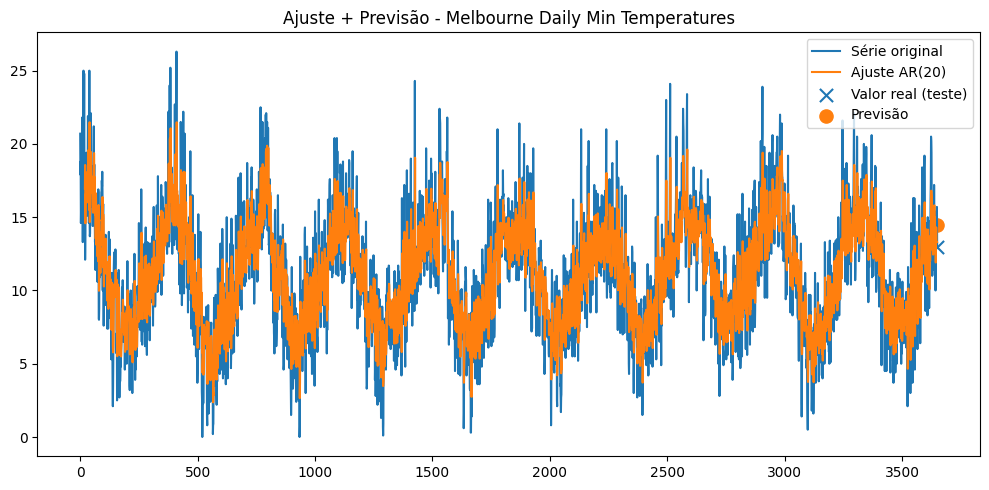


Diagnóstico dos resíduos
Ljung-Box (lag=20):
     lb_stat  lb_pvalue
20  3.480593   0.999985
p > 0.05: resíduos parecem ruído branco


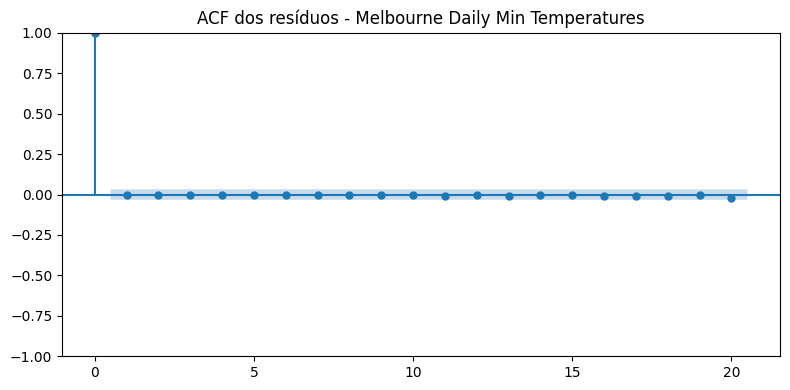

In [13]:
df_temp = pd.read_csv('data/daily_min_temp.csv')
serie_temp = pd.to_numeric(df_temp['Temp'], errors='coerce').dropna()
r2 = pipeline_ar(serie_temp, 'Melbourne Daily Min Temperatures')

### 4.3 Monthly Sunspots (esperado: **estacionária**)

DATASET: Monthly Sunspots


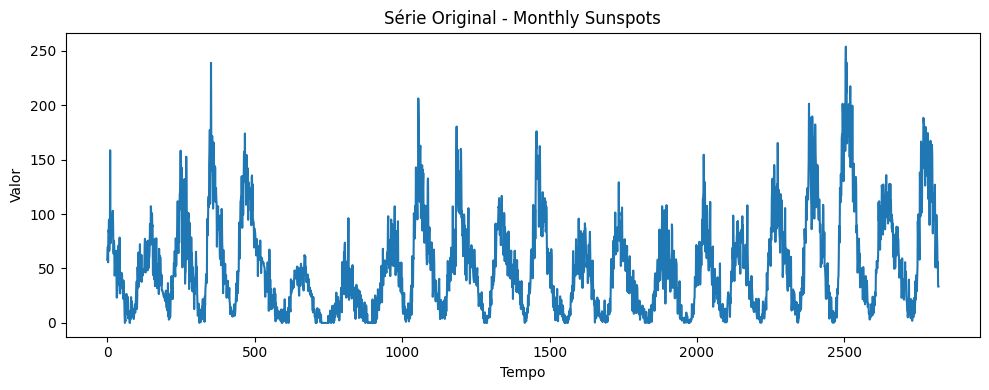

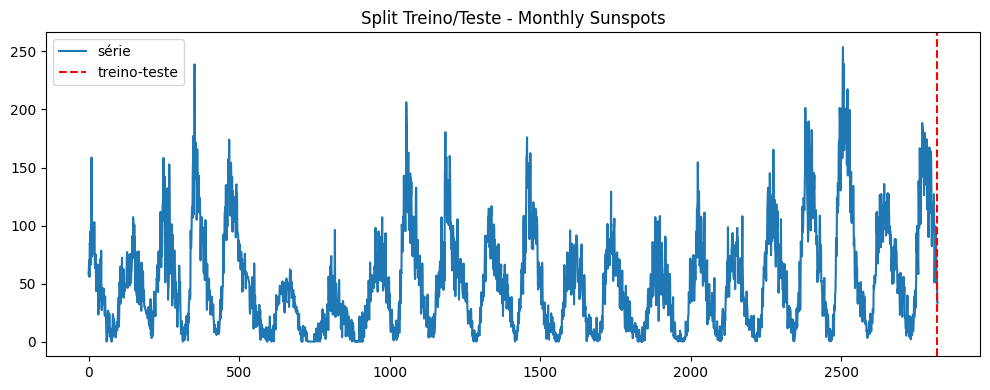

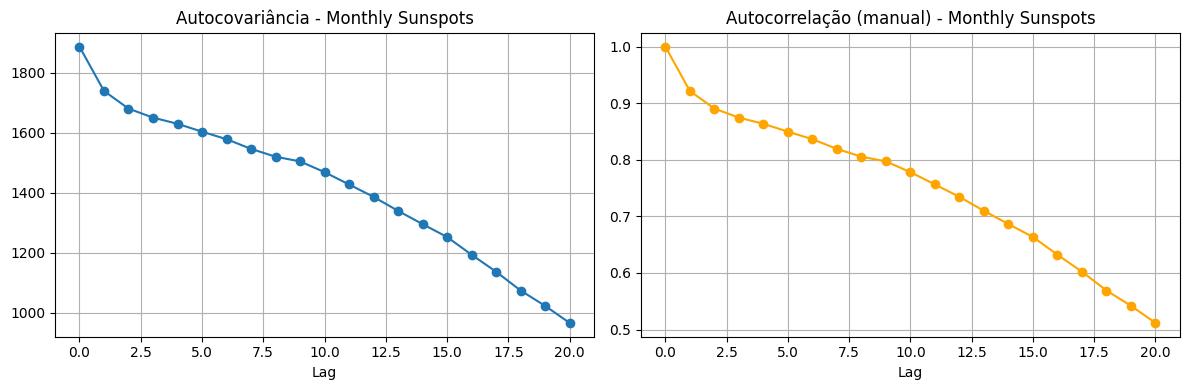

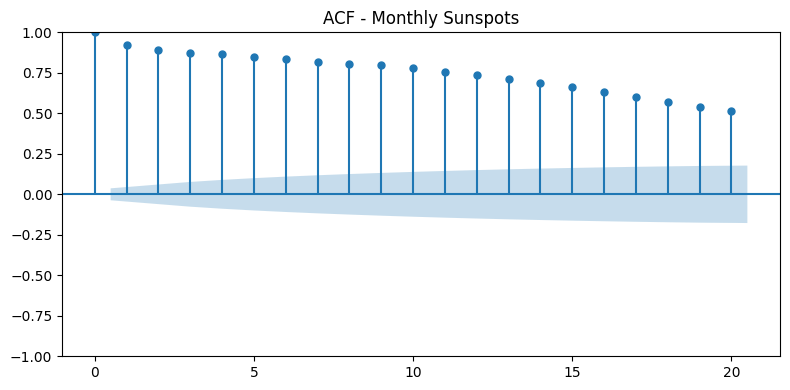

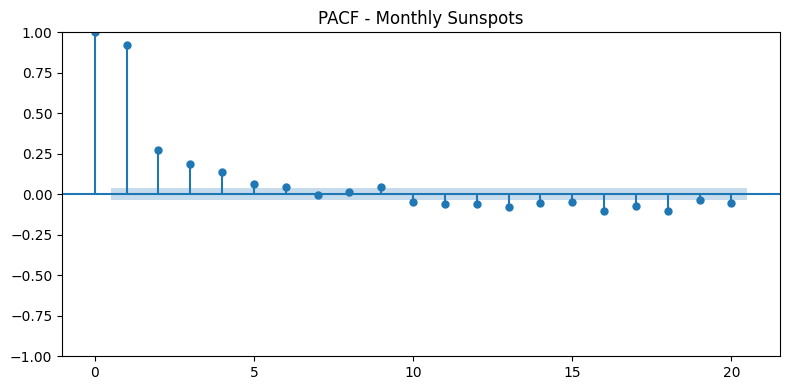


Teste KPSS
KPSS Statistic: 0.442499
p-value: 0.058837
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739

Teste ADF
ADF Statistic: -9.558006
p-value: 0.000000
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567

Decisão
ADF -> estacionária
KPSS -> estacionária
Veredito: ESTACIONÁRIA

Busca do melhor p (critério BIC)
Melhor p: 20
Menor BIC: 23369.1578

Previsão 1-step
Previsão : 41.6321
Real     : 33.4000
MAE      : 8.2321
MAPE     : 24.6470%


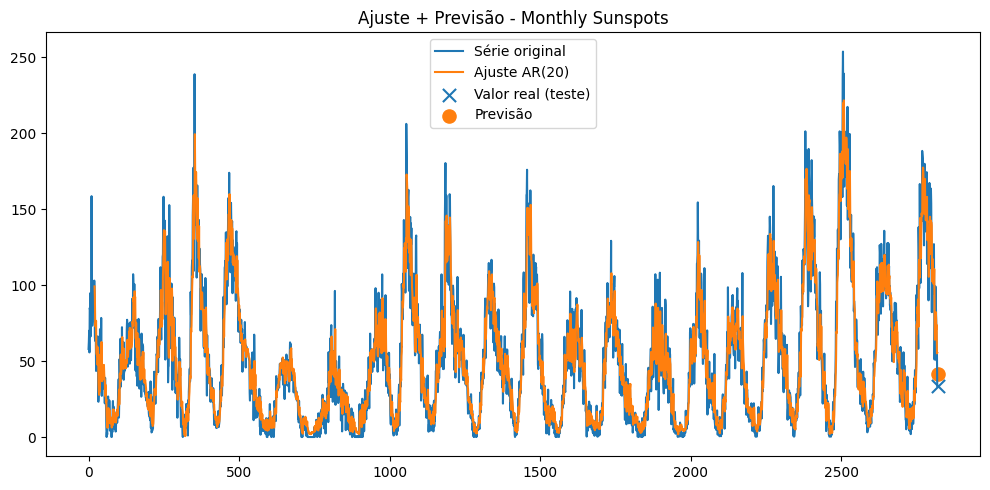


Diagnóstico dos resíduos
Ljung-Box (lag=20):
     lb_stat  lb_pvalue
20  9.828003   0.971185
p > 0.05: resíduos parecem ruído branco


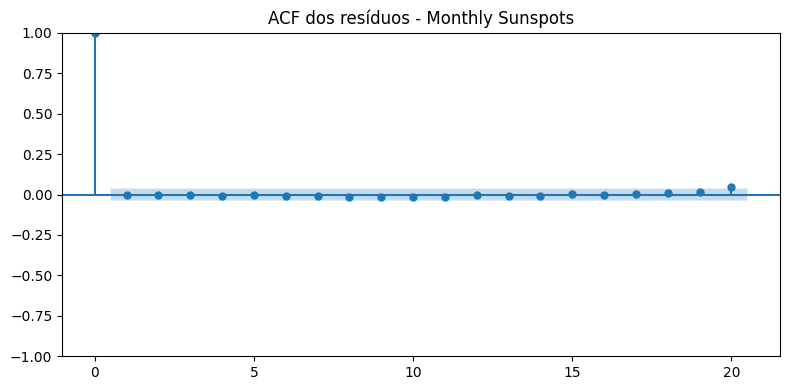

In [14]:
df_sun = pd.read_csv('data/sunspots.csv')
serie_sun = df_sun['Sunspots']
r3 = pipeline_ar(serie_sun, 'Monthly Sunspots')

### 4.4 Gold Prices (esperado: **não estacionária**)

DATASET: Monthly Gold Prices


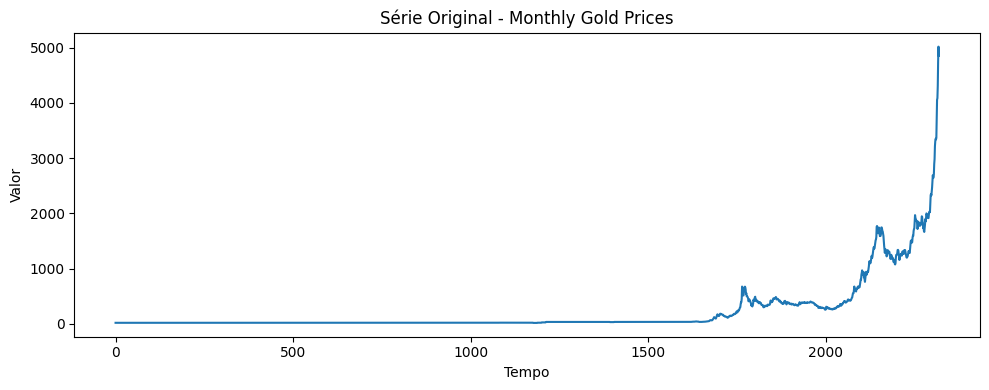

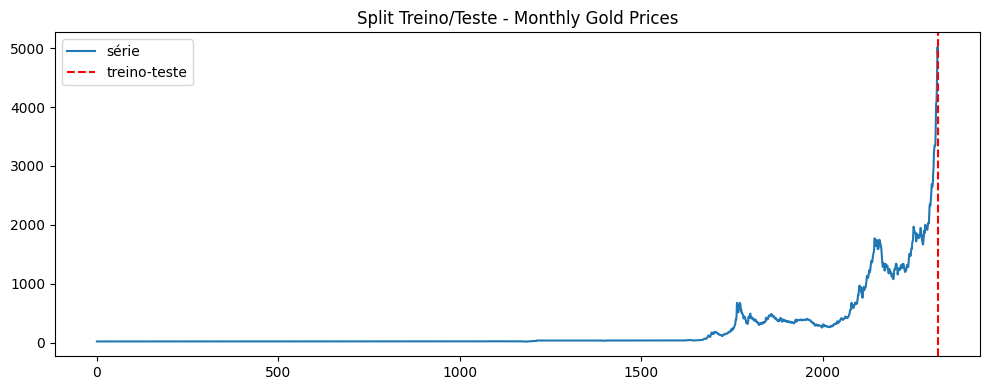

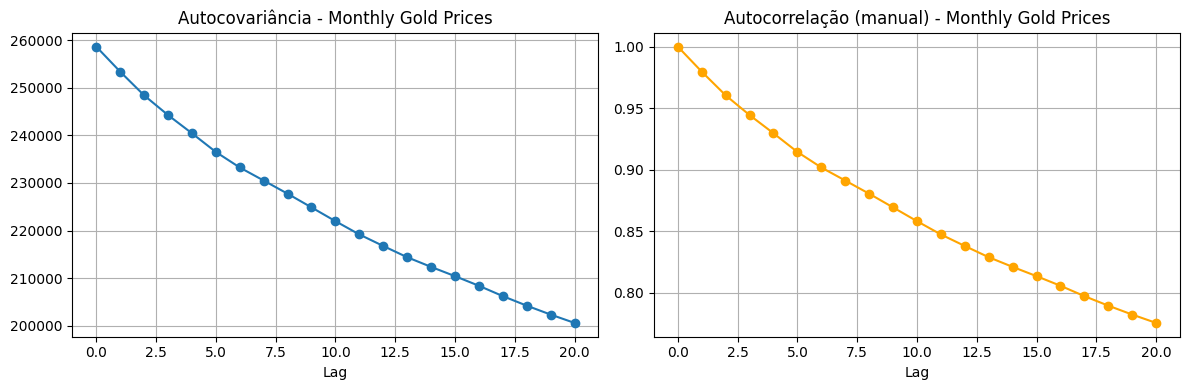

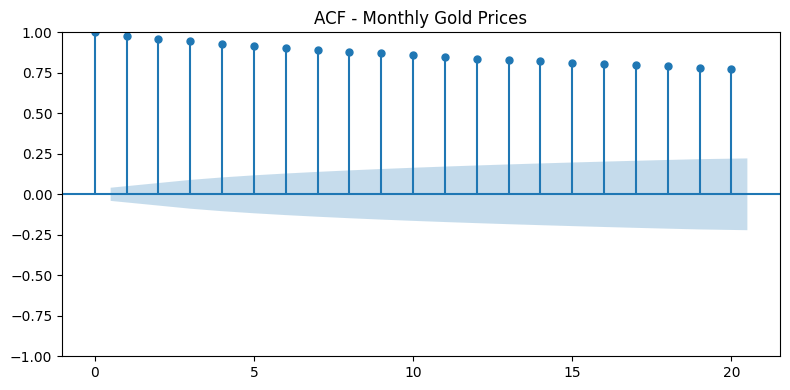

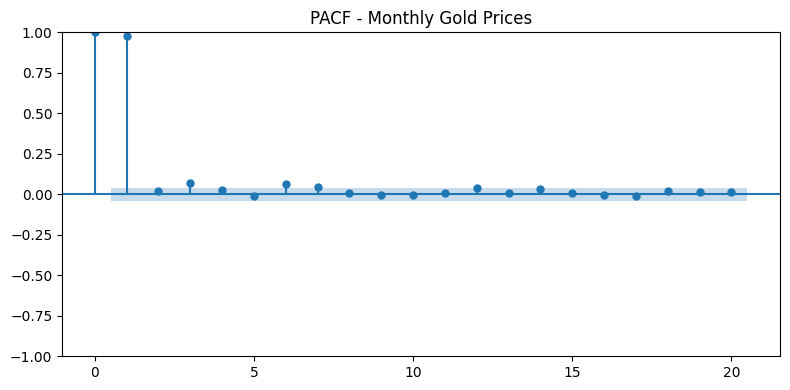


Teste KPSS
KPSS Statistic: 3.470011
p-value: 0.010000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739

Teste ADF
ADF Statistic: 3.488063
p-value: 1.000000
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567

Decisão
ADF -> NÃO estacionária
KPSS -> NÃO estacionária
Veredito: NÃO ESTACIONÁRIA

> Série não estacionária


In [15]:
df_gold = pd.read_csv('data/gold_prices.csv')
serie_gold = df_gold['Price']
r4 = pipeline_ar(serie_gold, 'Monthly Gold Prices')

## 5. Resumo consolidado

In [16]:
resumo = pd.DataFrame([r1, r2, r3, r4])
resumo

,dataset,estacionaria,p_adf,p_kpss,melhor_p,bic,previsao,real,mae,mape,ljung_box_p
0,Air Passengers,False,9.925254e-01,0.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Melbourne Daily Min Temperatures,True,2.553908e-04,0.100000,20.0,16827.034578,14.484155,13.0,1.484155,11.416575,0.999985
2,Monthly Sunspots,True,2.468938e-16,0.058837,20.0,23369.157770,41.632094,33.4,8.232094,24.646988,0.971185
3,Monthly Gold Prices,False,1.000000e+00,0.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
